In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts
import yaml

from pmt.io import *
from scipy.signal import find_peaks

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *
from pmt.fit import *
from pmt.fit.core import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
# file_name = "WA0089_750V_525MHz_led100" 
# file_name = "WA0089_775V_525MHz_led100" 
# file_name = "WA0089_800V_525MHz_led100" 
# file_name = "WA0089_825V_525MHz_led100"
file_name = "WA0089_850V_525MHz_led100"
# file_name = "WA0089_875V_525MHz_led100" 
# file_name = "WA0089_900V_525MHz_led100"
# file_name = "WA0089_925V_525MHz_led100"
# file_name = "WA0089_950V_525MHz_led100"
# file_name = "WA0089_975V_525MHz_led100" 
# file_name = "WA0089_1000V_525MHz_led100" 

channel="Channel 4"
data_dir = Path("data/WA0089/voltage_sweep/260706")
# Set to a number for quick iteration, or None to use all matching files.
max_files = 5



# save
save_plots = False
save_dir = 'plots/260706/fit'
file_nickname = f"{file_name}"
fit_inputs = "fit_data"

save_fit_res = "fit_results"
savefit_path = Path(f"{save_dir}/{save_fit_res}")
savefit_path.mkdir(parents=True, exist_ok=True)


In [3]:
df_file = Path(fit_inputs) / f"{file_nickname}_df.pkl"

if df_file.exists():
    print(f"Loading cached dataframe from {df_file}")
    df = pd.read_pickle(df_file)
else:
    print("Creating dataframe from raw waveforms...")
    chunk_size = 512 
    baseline_window_ns = (0, 20)
    files = find_pmt_files(data_dir, file_name, max_files=max_files)
    for file in files:
        print(file)
    print(f"Number of files loaded: {len(files)}")
    time_ns, waveforms_mV, df = load_files_one_go( files, chunk_size, baseline_window_ns, channel )
print(df.shape)

Loading cached dataframe from fit_data/WA0089_850V_525MHz_led100_df.pkl
(299915, 33)


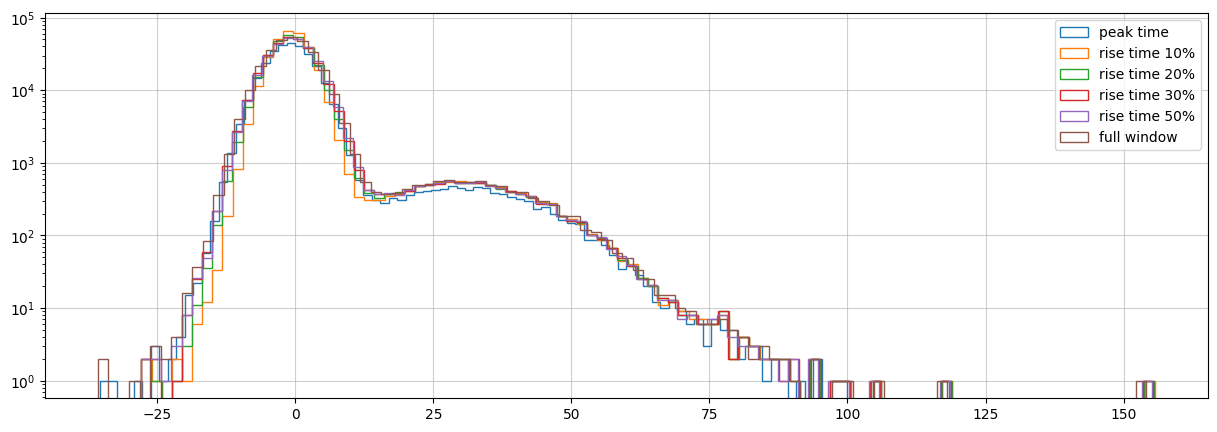

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns,                bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();




# Fit one step

In [5]:
charge_mV_ns = df.charge_cfd50_window_mV_ns.values # chose one charge distribution
fit_range_full = (np.min(charge_mV_ns), np.max(charge_mV_ns))
print(f"full range = ({fit_range_full[0]:.2f}, {fit_range_full[1]:.2f})")
fit_range = fit_range_full #(-16, 90)

full range = (-27.90, 155.14)


In [6]:
bins_list = [50, 75, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800, 900, 1000]
_ = scan_binning( charge_mV_ns, bins_list, fit_range=fit_range )
# _ = binning_diagnostics( charge_mV_ns, 250, fit_range=fit_range, verbose=True )

  Bins     Width      Mean    Median    Empty%       <5%     Min     Max
------------------------------------------------------------------------
    50      3.66    5998.3      17.5      24.0      42.0       0  103263
    75      2.44    3998.9       9.0      25.3      45.3       0   68532
   100      1.83    2999.2       8.0      29.0      46.0       0   52408
   150      1.22    1999.4       6.0      30.7      48.7       0   35397
   200     0.915    1499.6       5.0      34.0      49.5       0   26440
   250     0.732    1199.7       3.0      36.4      50.8       0   21268
   300      0.61     999.7       3.0      37.0      53.3       0   17720
   400     0.458     749.8       2.0      40.0      54.2       0   13278
   500     0.366     599.8       2.0      41.4      55.4       0   10658
   600     0.305     499.9       1.0      42.5      56.7       0    8920
   700     0.261     428.4       1.0      44.0      57.3       0    7652
   800     0.229     374.9       1.0      44.6     

In [7]:
nbins = 250
_ = binning_diagnostics( charge_mV_ns, nbins, fit_range=fit_range )

Binning diagnostics
----------------------------------------
Entries              : 299915
Bins                 : 250
Bin width            : 0.7322
Min count/bin        : 0
Max count/bin        : 21268
Mean count/bin       : 1199.66
Median count/bin     : 3.00
Empty bins           : 91 (36.4%)
Bins with <5 counts  : 127 (50.8%)


# Fit Config

In [8]:
# read config
with open('config_files/fit_config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)[file_name]
    try:
        fit_rg = cfg['fit_range']
    except:
        print('No fit range specified, using full range')
        fit_rg = fit_range_full

print(f'Fit range = {fit_rg}')

p0_poisson = cfg['poisson']['initPars']
p0_bellamy = cfg['bellamy']['initPars']
maxPE = 3

No fit range specified, using full range
Fit range = (np.float64(-27.901120387017734), np.float64(155.14431114122283))


## Poisson

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299915.0000 299714.4475     547.4744   [149957.5, 449872.5]   False
mu_pe                0.0600      0.0343       0.0004             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.6951       0.0075           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.9805       0.0056            [0.0, 50.0]   False
q1_mV_ns            29.0000     29.3408       0.2285            [1.0, 40.0]   False
sigma1_mV_ns        12.0000     12.8951       0.1858            [0.2, 20.0]   False

 Gain is 3.66e+06 +-2.85e+04 for Q1 = 29.340819815294015


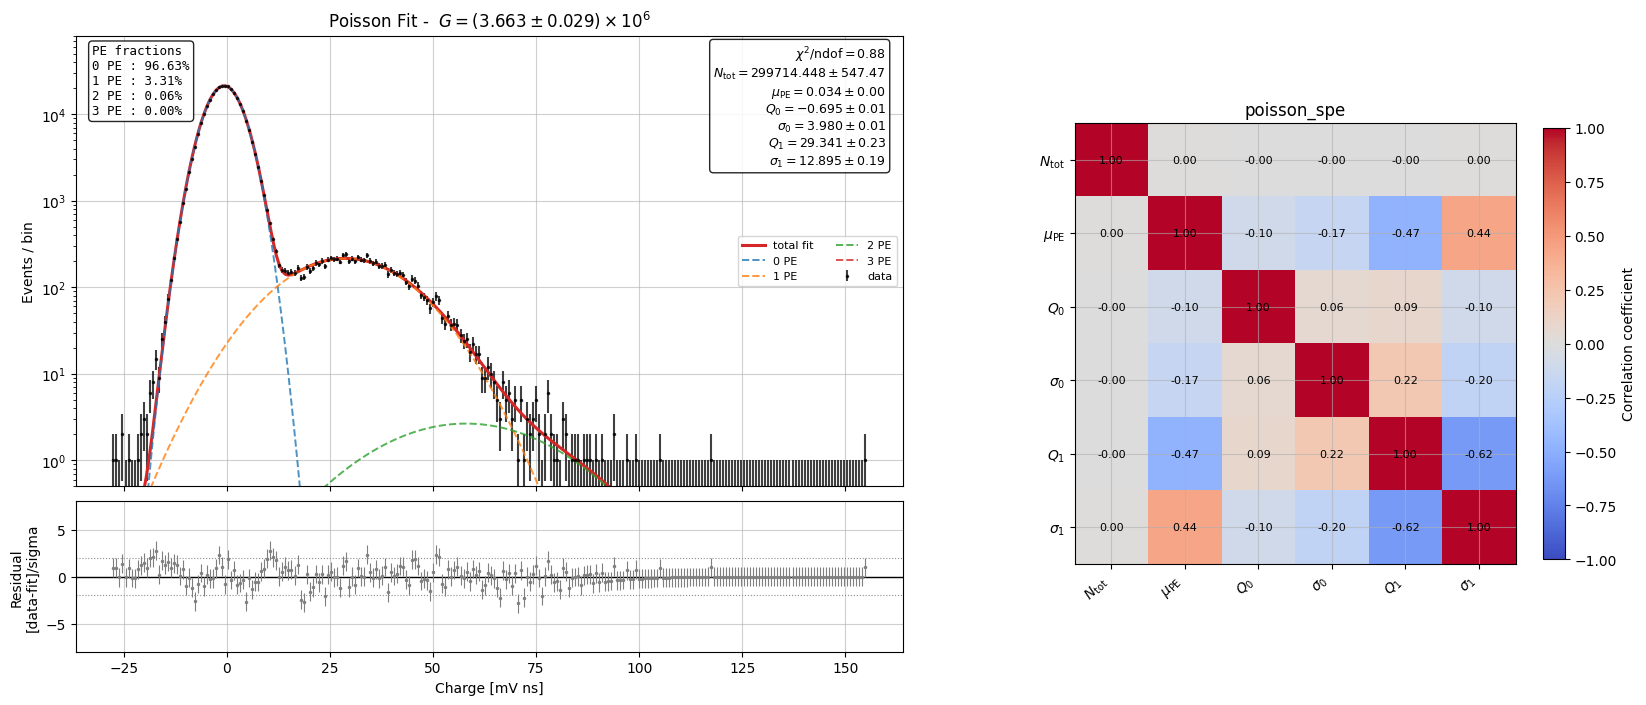

In [9]:
p0_poisson["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]

fit_poisson = fit_poisson_spe( charge_mV_ns, p0=p0_poisson, max_pe=maxPE, bins=nbins, fit_range=fit_rg )
print_fit_result_table(fit_poisson)
fit_poisson["diagnostics"]

G, G_err = compute_gain(fit_poisson['parameters']['q1_mV_ns'], fit_poisson['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_poisson['parameters']['q1_mV_ns']}")
exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Poisson Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_poisson, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson_{nbins}bins",  Nevents=None);

save_fit_results(fit_poisson, output_path=f"{savefit_path}/{file_nickname}_poisson.yaml");


## Bellamy

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         299915.0000 299738.6711     547.4958   [149957.5, 449872.5]   False
mu_pe                0.0600      0.0324       0.0009             [0.0, 5.0]   False
q0_mV_ns            -0.6000     -0.7420       0.0268           [-6.0, 10.0]   False
sigma0_mV_ns         3.9000      3.9565       0.0110            [0.0, 50.0]   False
q1_mV_ns            30.0000     30.5112       0.4859            [5.0, 50.0]   False
sigma1_mV_ns        12.0000     12.1829       0.2925            [0.2, 30.0]   False
w                    0.2000      0.0190       0.0132             [0.0, 1.0]   False
alpha                0.3000      0.2824       0.1328            [0.0, 10.0]   False
[]

 Gain is 3.81e+06 +-6.07e+04 for Q1 = 30.511194831111272


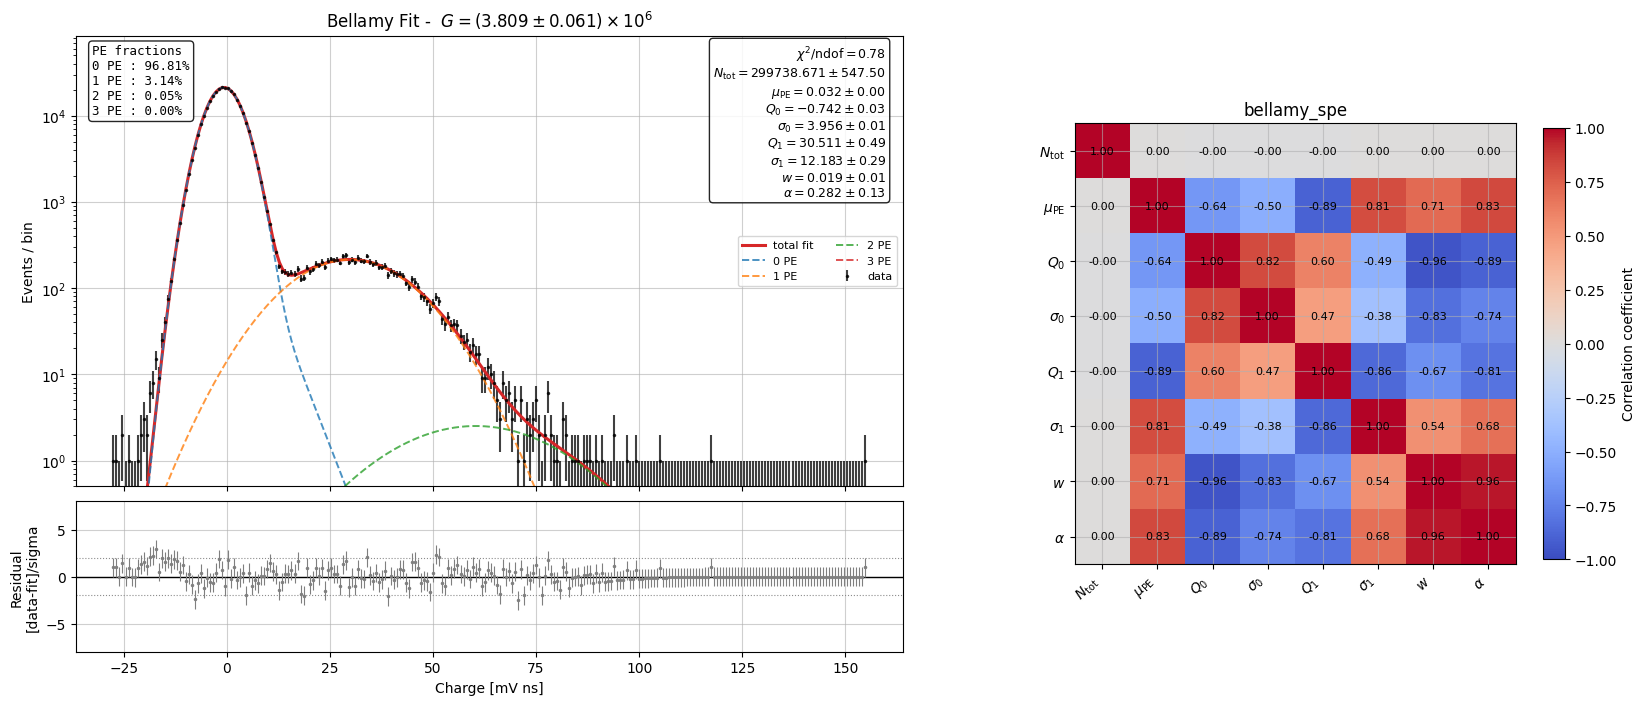

In [10]:
p0_bellamy["n_total"] = [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 1.5 * len(charge_mV_ns), False]
fit_bellamy = fit_bellamy_spe( charge_mV_ns, p0=p0_bellamy, max_pe=maxPE, bins=nbins, fit_range=fit_rg)

print_fit_result_table(fit_bellamy)
print(fit_bellamy["diagnostics"])

G, G_err = compute_gain(fit_bellamy['parameters']['q1_mV_ns'], fit_bellamy['errors']['q1_mV_ns'])
print(f"\n Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_bellamy['parameters']['q1_mV_ns']}")

exp = 6
G_scaled = G / 10**exp
Gerr_scaled = G_err / 10**exp
title = fr"Bellamy Fit -  $G = ({G_scaled:.3f} \pm {Gerr_scaled:.3f}) \times 10^{exp}$"

fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_bellamy, title=title, shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True,
                                                  show_event_fractions=True, max_fraction_pe=maxPE) 
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy_{nbins}bins",  Nevents=None);
save_fit_results(fit_bellamy, output_path=f"{savefit_path}/{file_nickname}_bellamy.yaml")


